### Swin Transformer (Classifier)
**Mục tiêu**: Train Transformer để phân loại bệnh.

**Output**: `models/swin_classifier.pth`


In [1]:
# Google Colab Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers timm torch torchvision scikit-learn seaborn tqdm -q


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Imports & Config
import os
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from transformers import SwinForImageClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")

if DEVICE.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU     : {gpu_name}")
    print(f"VRAM    : {vram_gb:.1f} GB")
    # BATCH_SIZE = 64    # L4
    BATCH_SIZE = 32    # T4 
else:
    vram_gb = 0
    BATCH_SIZE = 16

BASE_DIR     = Path("/content/drive/MyDrive/DATN")
CLF_DATA_DIR = BASE_DIR / "data" / "classifier"
MODELS_DIR   = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

MODEL_CKPT    = "microsoft/swin-small-patch4-window7-224"
NUM_EPOCHS    = 50
LR            = 1e-5
LR_HEAD       = 5e-5
MIN_LR        = 1e-7
WARMUP_EPOCHS = 5
NUM_WORKERS   = min(8, os.cpu_count() or 2)
IMG_SIZE      = 224

print(f"\nModel       : {MODEL_CKPT}")
print(f"Batch size  : {BATCH_SIZE}  (auto-detected cho {vram_gb:.0f}GB VRAM)")
print(f"Workers     : {NUM_WORKERS}")
print(f"Epochs      : {NUM_EPOCHS}  (warmup={WARMUP_EPOCHS})")
print(f"LR backbone : {LR}  |  LR head : {LR_HEAD}")

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB

Model       : microsoft/swin-small-patch4-window7-224
Batch size  : 32  (auto-detected cho 16GB VRAM)
Workers     : 2
Epochs      : 50  (warmup=5)
LR backbone : 1e-05  |  LR head : 5e-05


In [ ]:
import shutil, subprocess, zipfile

LOCAL_CLF_DIR = Path('/content/clf_data')
DRIVE_TAR = BASE_DIR / 'data' / 'classifier.tar'
DOWNLOAD_DIR = Path('/content/plantvillage_raw')


def count_images(folder):
    return sum(1 for _ in folder.rglob('*.jpg')) + sum(1 for _ in folder.rglob('*.png'))


def has_existing_splits(clf_dir):
    return all(
        (clf_dir / sp).exists() and count_images(clf_dir / sp) > 100
        for sp in ('train', 'valid', 'test')
    )


if has_existing_splits(LOCAL_CLF_DIR):
    counts = {sp: count_images(LOCAL_CLF_DIR / sp) for sp in ('train', 'valid', 'test')}
    print(f"Data local đã có — bỏ qua download")
    print(f"  train={counts['train']:,} | valid={counts['valid']:,} | test={counts['test']:,}")

elif DRIVE_TAR.exists():
    # Extract từ Drive tar
    if LOCAL_CLF_DIR.exists():
        shutil.rmtree(LOCAL_CLF_DIR)
    LOCAL_CLF_DIR.mkdir(parents=True)

    local_tar = Path('/content/classifier.tar')
    tar_size = DRIVE_TAR.stat().st_size / 1e9
    print(f"Copy tar ({tar_size:.2f} GB): Drive → SSD...")
    t0 = time.time()
    shutil.copy2(str(DRIVE_TAR), str(local_tar))
    print(f"  Done ({time.time() - t0:.0f}s)")

    print("Extract...")
    t0 = time.time()
    subprocess.run(['tar', '-xf', str(local_tar), '-C', str(LOCAL_CLF_DIR)], check=True)
    local_tar.unlink()
    print(f"  Done ({time.time() - t0:.0f}s)")

else:
    # Download từ Kaggle
    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    kaggle_dir = Path('/root/.kaggle')
    kaggle_dir.mkdir(exist_ok=True)
    kaggle_json = kaggle_dir / 'kaggle.json'
    kaggle_json.write_text(json.dumps({"username": "seotoww", "key": "7906ccbc30f5ece58ddca958219a9ecb"}))
    kaggle_json.chmod(0o600)

    print("Download PlantVillage từ Kaggle...")
    subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', 'abdallahalidev/plantvillage-dataset',
        '-p', str(DOWNLOAD_DIR)
    ], check=True)

    zip_path = next(DOWNLOAD_DIR.glob('*.zip'))
    print(f"Extract {zip_path.name}...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DOWNLOAD_DIR)

    # Tìm thư mục chứa ảnh (color images)
    color_dir = None
    for candidate in DOWNLOAD_DIR.rglob('color'):
        if candidate.is_dir() and count_images(candidate) > 1000:
            color_dir = candidate
            break
    if color_dir is None:
        color_dir = next(d for d in DOWNLOAD_DIR.rglob('*') if d.is_dir() and count_images(d) > 1000)

    # Stratified split 80/10/10
    from sklearn.model_selection import train_test_split

    LOCAL_CLF_DIR.mkdir(parents=True, exist_ok=True)
    class_dirs = sorted([d for d in color_dir.iterdir() if d.is_dir()])

    for cls_dir in tqdm(class_dirs, desc='Splitting'):
        imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.JPG')) + list(cls_dir.glob('*.png'))
        if not imgs:
            continue
        train_val, test = train_test_split(imgs, test_size=0.1, random_state=SEED)
        train, valid = train_test_split(train_val, test_size=0.111, random_state=SEED)

        for split_name, split_imgs in [('train', train), ('valid', valid), ('test', test)]:
            dst_dir = LOCAL_CLF_DIR / split_name / cls_dir.name
            dst_dir.mkdir(parents=True, exist_ok=True)
            for img in split_imgs:
                shutil.copy2(str(img), str(dst_dir / img.name))

    counts = {sp: count_images(LOCAL_CLF_DIR / sp) for sp in ('train', 'valid', 'test')}
    print(f"Split hoàn tất: train={counts['train']:,} | valid={counts['valid']:,} | test={counts['test']:,}")

# Dọn folder rỗng
for sp in ('train', 'valid', 'test'):
    sp_dir = LOCAL_CLF_DIR / sp
    if not sp_dir.exists():
        continue
    for cls_dir in sp_dir.iterdir():
        if cls_dir.is_dir() and count_images(cls_dir) == 0:
            shutil.rmtree(cls_dir)

print(f"\nData SSD: {LOCAL_CLF_DIR}")

In [4]:
# Load dữ liệu
import shutil
import subprocess

LOCAL_CLF_DIR = Path("/content/clf_data")
DRIVE_TAR     = BASE_DIR / "data" / "classifier.tar"
LOCAL_TAR     = Path("/content/classifier.tar")


def count_images(folder):
    return sum(1 for _ in folder.rglob("*.jpg")) + sum(1 for _ in folder.rglob("*.png"))


splits_ready = all(
    (LOCAL_CLF_DIR / sp).exists() and count_images(LOCAL_CLF_DIR / sp) > 100
    for sp in ('train', 'valid', 'test')
)

if splits_ready:
    split_counts = {sp: count_images(LOCAL_CLF_DIR / sp) for sp in ('train', 'valid', 'test')}
    print(f"Data local da co — bo qua extract")
    print(f"   train={split_counts['train']:,} | valid={split_counts['valid']:,} | test={split_counts['test']:,}")
else:
    if not DRIVE_TAR.exists():
        raise FileNotFoundError(
            f"Khong tim thay {DRIVE_TAR}\n"
            f"   Chay notebook 02_prepare_classifier_data.ipynb truoc."
        )

    if LOCAL_CLF_DIR.exists():
        shutil.rmtree(LOCAL_CLF_DIR)
    LOCAL_CLF_DIR.mkdir(parents=True)

    tar_size_gb = DRIVE_TAR.stat().st_size / 1e9
    print(f"Copy tar ({tar_size_gb:.2f} GB): Drive -> /content/ ...")
    t0 = time.time()
    shutil.copy2(str(DRIVE_TAR), str(LOCAL_TAR))
    print(f"   Done ({time.time()-t0:.0f}s)")

    print("Extract -> /content/clf_data/ ...")
    t0 = time.time()
    ret = subprocess.run(
        ["tar", "-xf", str(LOCAL_TAR), "-C", str(LOCAL_CLF_DIR)],
        capture_output=True, text=True
    )
    if ret.returncode != 0:
        raise RuntimeError(f"tar extract failed: {ret.stderr}")
    LOCAL_TAR.unlink()
    print(f"San sang ({time.time()-t0:.0f}s) — {LOCAL_CLF_DIR}")

# Don sach folder rong
SPLITS = ('train', 'valid', 'test')
for sp in SPLITS:
    sp_dir = LOCAL_CLF_DIR / sp
    if not sp_dir.exists():
        continue
    removed = []
    for cls_dir in sp_dir.iterdir():
        if cls_dir.is_dir():
            imgs = (list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.JPG"))
                  + list(cls_dir.glob("*.png")) + list(cls_dir.glob("*.PNG"))
                  + list(cls_dir.glob("*.jpeg")))
            if len(imgs) == 0:
                shutil.rmtree(cls_dir)
                removed.append(cls_dir.name)
    if removed:
        print(f"[{sp}] Xoa {len(removed)} folder rong: {removed[:3]}{'...' if len(removed)>3 else ''}")

# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ImageFolder
train_ds = datasets.ImageFolder(str(LOCAL_CLF_DIR / 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(str(LOCAL_CLF_DIR / 'valid'), transform=eval_transform)
test_ds  = datasets.ImageFolder(str(LOCAL_CLF_DIR / 'test'),  transform=eval_transform)

val_ds.class_to_idx  = train_ds.class_to_idx
val_ds.classes       = train_ds.classes
test_ds.class_to_idx = train_ds.class_to_idx
test_ds.classes      = train_ds.classes

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")

# WeightedRandomSampler
label_list     = [label for _, label in train_ds.imgs]
class_counts   = Counter(label_list)
inv_freq       = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [inv_freq[label] for label in label_list]

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

counts_list = [class_counts.get(i, 0) for i in range(NUM_CLASSES)]
print(f"Imbalance: max={max(counts_list):,} | min={min(counts_list)} | "
      f"ratio={max(counts_list)/max(1, min(counts_list)):.1f}x")
print(f"DataLoaders san sang — batch={BATCH_SIZE}, workers={NUM_WORKERS}")

Copy tar (0.91 GB): Drive -> /content/ ...
   Done (48s)
Extract -> /content/clf_data/ ...
San sang (34s) — /content/clf_data
Classes: 38
Train: 43,428 | Val: 5,417 | Test: 5,459
Imbalance: max=4,405 | min=121 | ratio=36.4x
DataLoaders san sang — batch=32, workers=2


In [4]:
# Load Pretrained Swin Transformer
model = SwinForImageClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=NUM_CLASSES,
    id2label={str(i): n for i, n in enumerate(CLASS_NAMES)},
    label2id={n: i for i, n in enumerate(CLASS_NAMES)},
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params : {total_params:,}")
print(f"Trainable    : {trainable_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([38])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([38, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params   : 48,866,480
Trainable      : 48,866,480

✅ Model loaded và sẵn sàng fine-tune


In [ ]:
# Training Loop

# Class-weighted loss
counts_arr    = np.array([class_counts.get(i, 1) for i in range(NUM_CLASSES)], dtype=np.float32)
inv_freq_arr  = 1.0 / counts_arr
class_weights = torch.tensor(
    inv_freq_arr / inv_freq_arr.sum() * NUM_CLASSES,
    dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Differential LR: backbone nhỏ, head lớn
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params     = [p for n, p in model.named_parameters() if 'classifier' in n]
optimizer = AdamW([
    {'params': backbone_params, 'lr': LR,      'name': 'backbone'},
    {'params': head_params,     'lr': LR_HEAD,  'name': 'head'},
], weight_decay=0.01)

# Scheduler: Linear warmup -> CosineAnnealingLR
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=MIN_LR)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                            milestones=[WARMUP_EPOCHS])

# Mixed Precision (AMP)
USE_AMP = DEVICE.type == 'cuda'
scaler  = torch.cuda.amp.GradScaler(enabled=USE_AMP)
print(f"AMP       : {'bật' if USE_AMP else 'tắt (không có GPU)'}")
print(f"Scheduler : warmup ({WARMUP_EPOCHS} ep) -> CosineAnnealingLR")
print(f"LR backbone={LR} | LR head={LR_HEAD} | MIN_LR={MIN_LR}")

history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_ckpt    = MODELS_DIR / 'swin_classifier_best.pth'
last_ckpt    = MODELS_DIR / 'swin_classifier_last.pth'
start_epoch  = 1

# Resume từ checkpoint nếu bị ngắt giữa chừng
if last_ckpt.exists():
    print(f"\nCheckpoint cũ: {last_ckpt}")
    ckpt_r       = torch.load(str(last_ckpt), map_location=DEVICE, weights_only=False)
    ckpt_num_cls = ckpt_r.get('num_labels', -1)

    if ckpt_num_cls != NUM_CLASSES:
        print(f"   Checkpoint có {ckpt_num_cls} classes, model hiện tại có {NUM_CLASSES} classes.")
        print(f"   Không thể resume — bắt đầu training mới.")
    else:
        resume = input("   Resume training? [y/N]: ").strip().lower()
        if resume == 'y':
            model.load_state_dict(ckpt_r['model_state'])
            try:
                optimizer.load_state_dict(ckpt_r['optimizer'])
                scheduler.load_state_dict(ckpt_r['scheduler'])
            except Exception as e:
                print(f"   Không load được optimizer/scheduler ({e}) — giữ lr mới.")
            if 'scaler' in ckpt_r:
                scaler.load_state_dict(ckpt_r['scaler'])
            history      = ckpt_r['history']
            best_val_acc = ckpt_r['best_val_acc']
            start_epoch  = ckpt_r['epoch'] + 1
            print(f"   Resumed từ epoch {ckpt_r['epoch']} | best_val_acc={best_val_acc:.4f}")
            print(f"   Tiếp tục từ epoch {start_epoch} -> {NUM_EPOCHS}")
        else:
            print("   Bắt đầu training mới.")
else:
    print("Không có checkpoint cũ — training mới.")


def run_epoch(loader, is_train=True, desc=""):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(loader, desc=desc, leave=False,
                bar_format="{l_bar}{bar:20}{r_bar}", ncols=90)
    with ctx:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(pixel_values=imgs).logits
                loss    = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * imgs.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            pbar.set_postfix(loss=f"{total_loss/total:.4f}",
                             acc=f"{correct/total:.3f}")
    return total_loss / total, correct / total


print(f"\nTraining epoch {start_epoch}->{NUM_EPOCHS} | {len(train_loader)} batches/epoch")
print("─" * 85)

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, is_train=True,  desc=f"Ep{epoch:02d} Train")
    va_loss, va_acc = run_epoch(val_loader,   is_train=False, desc=f"Ep{epoch:02d} Val  ")
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]
    marker  = " [best]" if va_acc > best_val_acc else ""
    phase   = "warmup" if epoch <= WARMUP_EPOCHS else "cosine"
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} [{phase}] | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={va_loss:.4f} acc={va_acc:.3f} | "
          f"lr={lr_now:.1e} | {elapsed:.0f}s{marker}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_acc'     : va_acc,
            'class_names' : CLASS_NAMES,
            'model_ckpt'  : MODEL_CKPT,
            'num_labels'  : NUM_CLASSES,
        }, str(best_ckpt))

    torch.save({
        'epoch'        : epoch,
        'model_state'  : model.state_dict(),
        'optimizer'    : optimizer.state_dict(),
        'scheduler'    : scheduler.state_dict(),
        'scaler'       : scaler.state_dict(),
        'history'      : history,
        'best_val_acc' : best_val_acc,
        'class_names'  : CLASS_NAMES,
        'model_ckpt'   : MODEL_CKPT,
        'num_labels'   : NUM_CLASSES,
    }, str(last_ckpt))

print("─" * 85)
print(f"Training hoàn tất. Best val acc = {best_val_acc*100:.2f}%")
print(f"Best : {best_ckpt}")
print(f"Last : {last_ckpt}")


/tmp/ipykernel_7973/4108500857.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Mixed Precision (AMP) : ✅ BẬT
Scheduler             : Linear warmup (5 ep) → CosineAnnealingLR
LR backbone=1e-05 | LR head=5e-05 | MIN_LR=1e-07

🔄 Phát hiện checkpoint cũ: /content/drive/MyDrive/DATN/models/swin_classifier_last.pth


model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

   Bắt đầu training mới từ đầu.

Bắt đầu training — epoch 1→50 | 679 batches/epoch
─────────────────────────────────────────────────────────────────────────────────────


Ep01 Train:   0%|                    | 0/679 [00:00<?, ?it/s]

...

Ep49 Val  :   0%|                    | 0/85 [00:00<?, ?it/s]

Epoch 49/50 [cosine] | train loss=0.6204 acc=0.999 | val loss=1.6162 acc=0.999 | lr=1.1e-07 | 278s


Ep50 Train:   0%|                    | 0/679 [00:00<?, ?it/s]

Ep50 Val  :   0%|                    | 0/85 [00:00<?, ?it/s]

Epoch 50/50 [cosine] | train loss=0.6202 acc=0.999 | val loss=1.6161 acc=0.999 | lr=1.0e-07 | 279s ✅ best
─────────────────────────────────────────────────────────────────────────────────────
✅ Training hoàn tất! Best val acc = 99.94%
   Best : /content/drive/MyDrive/DATN/models/swin_classifier_best.pth
   Last : /content/drive/MyDrive/DATN/models/swin_classifier_last.pth


In [5]:
# Plot Training Curves
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-', label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs, [x*100 for x in history['train_acc']], 'b-', label='Train Acc')
ax2.plot(epochs, [x*100 for x in history['val_acc']],   'r-', label='Val Acc')
best_ep = np.argmax(history['val_acc']) + 1
ax2.axvline(best_ep, color='g', linestyle='--', label=f'Best epoch={best_ep}')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)
ax2.set_ylim(0, 105)

plt.suptitle(f'Swin-Small Fine-tuning — Best Val Acc: {best_val_acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'swin_training_curves.png'), dpi=150)
plt.show()

NameError: name 'history' is not defined

In [7]:
# Danh gia tren tap TEST
ckpt = torch.load(str(best_ckpt), map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f})")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        imgs   = imgs.to(DEVICE)
        logits = model(pixel_values=imgs).logits
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Loaded best checkpoint (epoch 50, val_acc=0.9994)


Testing:   0%|          | 0/86 [00:00<?, ?it/s]


✅ Test Accuracy: 99.91%


Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      1.000     1.000     1.000        63
                                 Apple___Black_rot      1.000     1.000     1.000        63
                          Apple___Cedar_apple_rust      1.000     1.000     1.000        28
                                   Apple___healthy      1.000     1.000     1.000       165
                               Blueberry___healthy      1.000     1.000     1.000       151
          Cherry_(including_sour)___Powdery_mildew      1.000     1.000     1.000       106
                 Cherry_(including_sour)___healthy      1.000     0.988     0.994        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.981     0.981     0.981        52
                       Corn_(maize)___Common_rust_      1.000     1.000     1.000       120
               Corn_(maize)___Northern_Leaf_Blight      

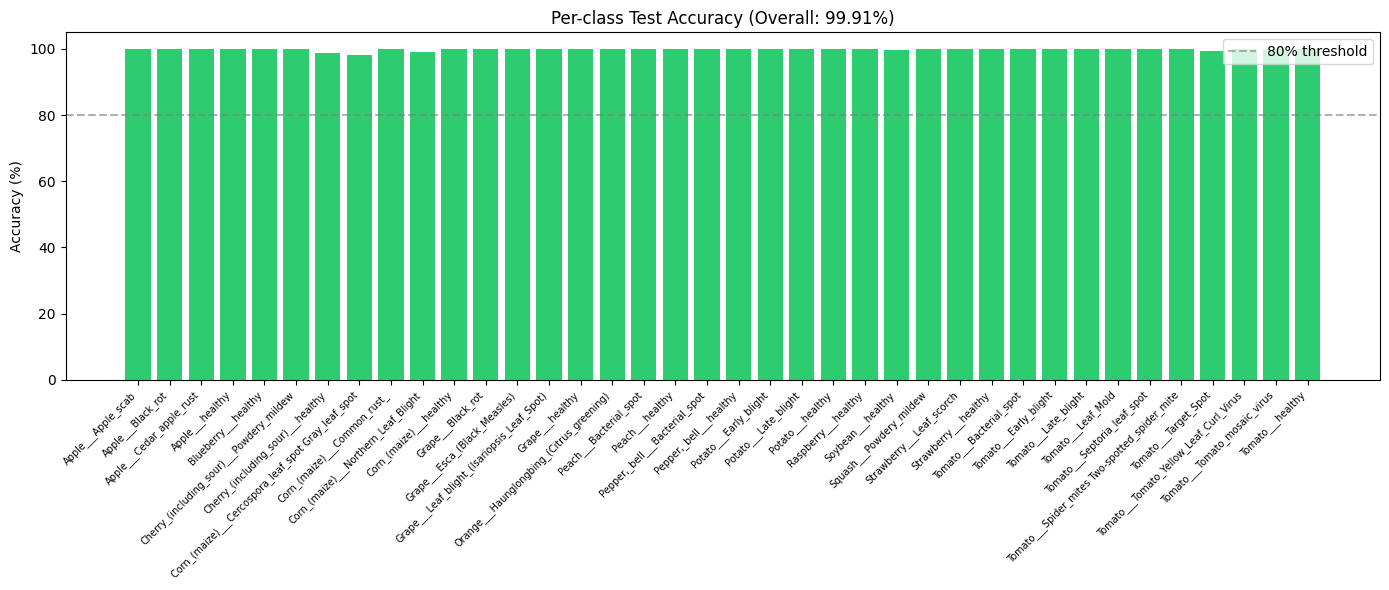

In [8]:
# Per-class Accuracy & Classification Report
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

per_class_acc = []
for i, name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    acc  = (all_preds[mask] == all_labels[mask]).mean() if mask.sum() > 0 else 0
    per_class_acc.append(acc)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e74c3c' if a < 0.5 else '#f39c12'
          for a in per_class_acc]
ax.bar(range(NUM_CLASSES), [a*100 for a in per_class_acc], color=colors)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Per-class Test Accuracy (Overall: {test_acc*100:.2f}%)')
ax.legend()
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'swin_per_class_accuracy.png'), dpi=150)
plt.show()

In [9]:
# Luu model
final_path = MODELS_DIR / 'swin_classifier.pth'
torch.save(ckpt, str(final_path))
print(f"Saved: {final_path}")

print("\n" + "="*50)
print("TỔNG KẾT TRAINING")
print("="*50)
print(f"Model         : {MODEL_CKPT}")
print(f"Num classes   : {NUM_CLASSES}")
print(f"Best epoch    : {ckpt['epoch']}")
print(f"Val accuracy  : {ckpt['val_acc']*100:.2f}%")
print(f"Test accuracy : {test_acc*100:.2f}%")
print(f"Model path    : {final_path}")


✅ Saved final model → /content/drive/MyDrive/DATN/models/swin_classifier.pth

TỔNG KẾT TRAINING
Model         : microsoft/swin-small-patch4-window7-224
Num classes   : 38
Best epoch    : 50
Val accuracy  : 99.94%
Test accuracy : 99.91%
Model path    : /content/drive/MyDrive/DATN/models/swin_classifier.pth
